## **ASD Classification**

The same model instance is first evaluated (zero-shot), then fine-tuned, then re-evaluated — memory efficient.






Using device: cuda
STEP 1: Loading Data for Target = 'ASD'
✅ Loaded 414 ROI labels from dataset/roi_labels.csv
✓ All required columns present

STEP 2: Preparing Data Loaders
🧼 Cohort: 585 subjects (271 cases, 314 controls, 46.3% prevalence)
✅ Splits → Train: 409, Val: 88, Test: 88

📊 Dataset Meta
  target: ASD
  n_total: 585
  n_positive: 271
  prevalence: 0.4632478654384613
  feature_dim: 414
  n_train: 409
  n_val: 88
  n_test: 88

STEP 3: Initializing BBTransformer
✓ Model created on CPU with 25,878,114 parameters

STEP 3.5: Loading Pretrained Weights for Zero-Shot
Attempting SAFE load (on CPU first): /home/jaizor/jaizor/xtra/notebooks/UKBB/scripts/weights/weights_ASD.pth
✓ Successfully loaded 87 layers from: /home/jaizor/jaizor/xtra/notebooks/UKBB/scripts/weights/weights_ASD.pth
✓ Pretrained weights loaded.

STEP 4: Zero-Shot Evaluation (No Training)



🧪 Zero-Shot Metrics:
  Accuracy: 0.4659
  Precision: 0.4500
  Recall: 0.6585
  F1: 0.5347
  Roc_auc: 0.4450


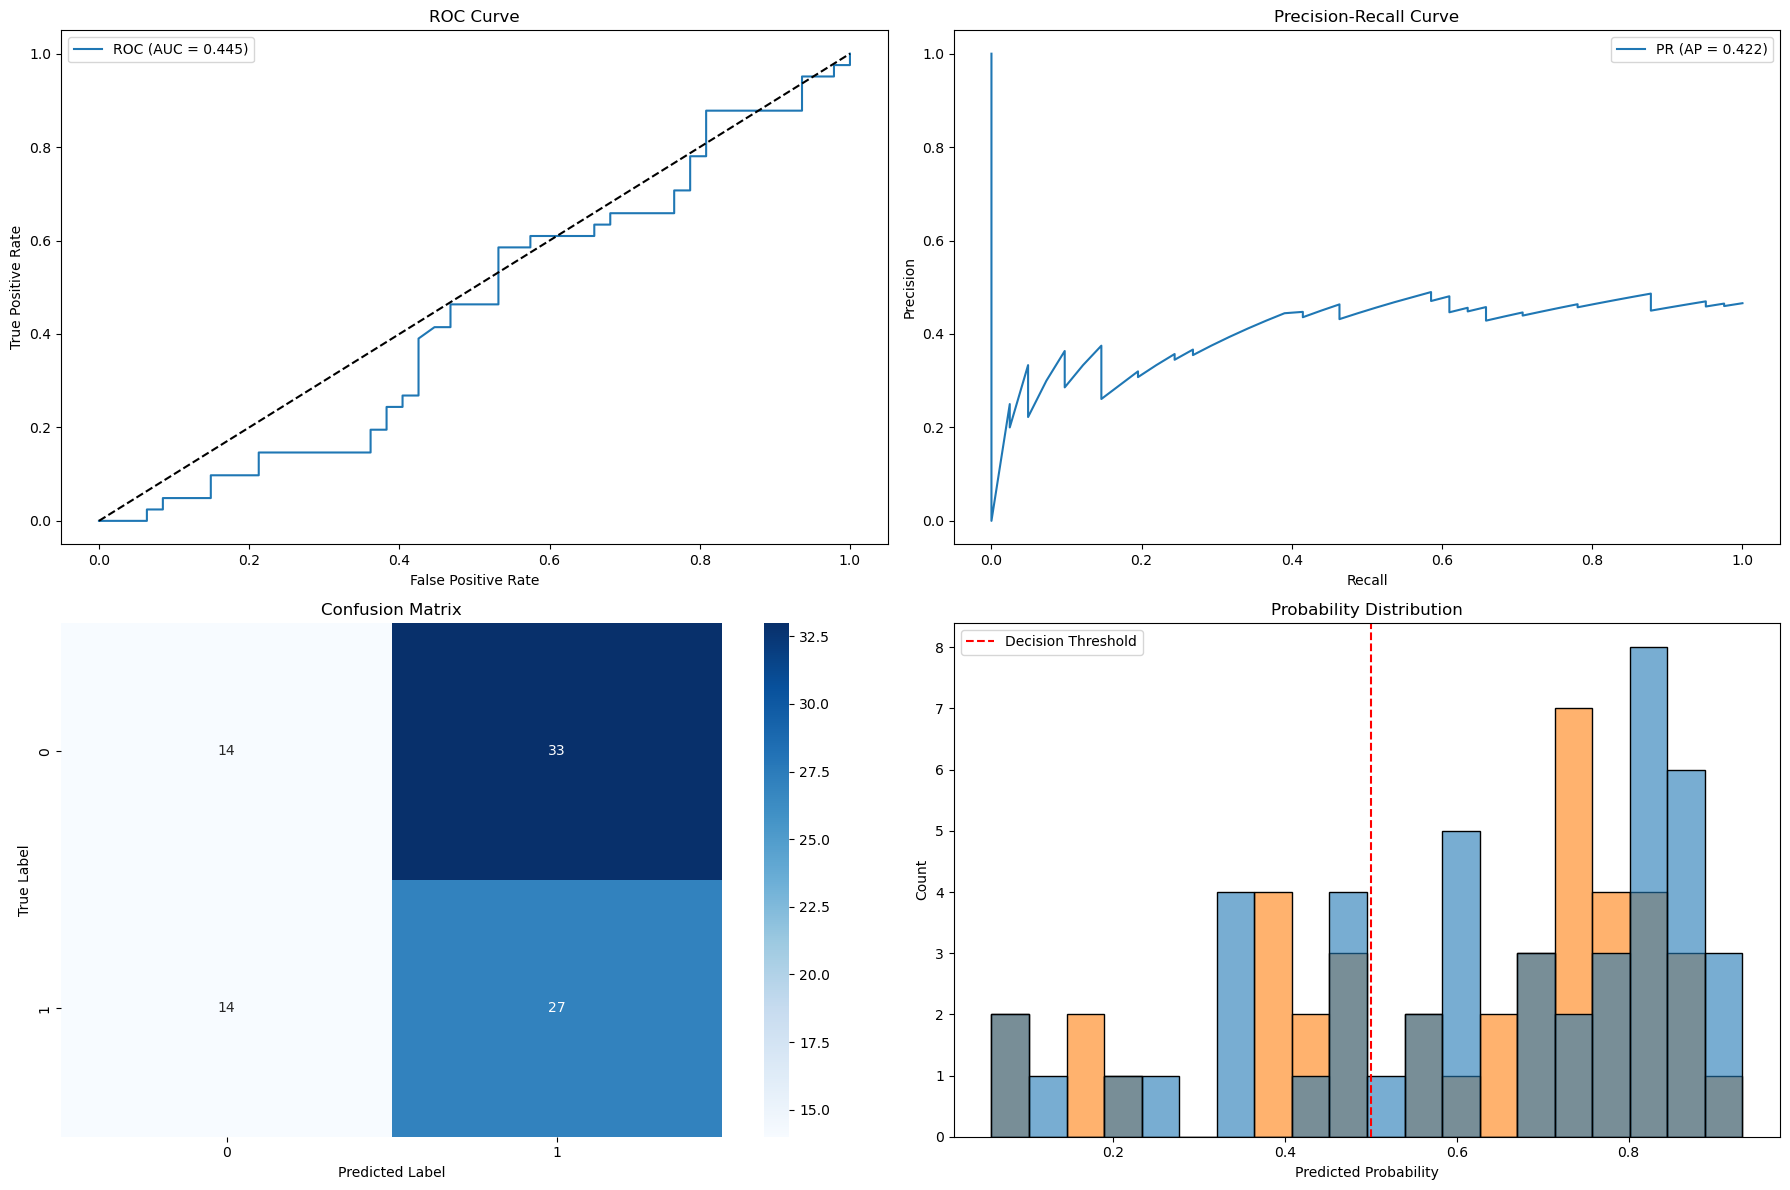

✅ Saved evaluation plots to results/ASD_zeroshot_results.png

STEP 5: Fine-Tuning with Ranger21


Early stopping triggered at epoch 230 (loss: 0.8734)

✅ Fine-tuning complete!
✓ Saved SAFE weights (weights_only=True compatible) to: weights/weights_ASD.pth

STEP 6: Evaluation After Fine-Tuning



🧪 Fine-Tuned Metrics:
  Accuracy: 0.6591
  Precision: 0.6038
  Recall: 0.7805
  F1: 0.6809
  Roc_auc: 0.6998


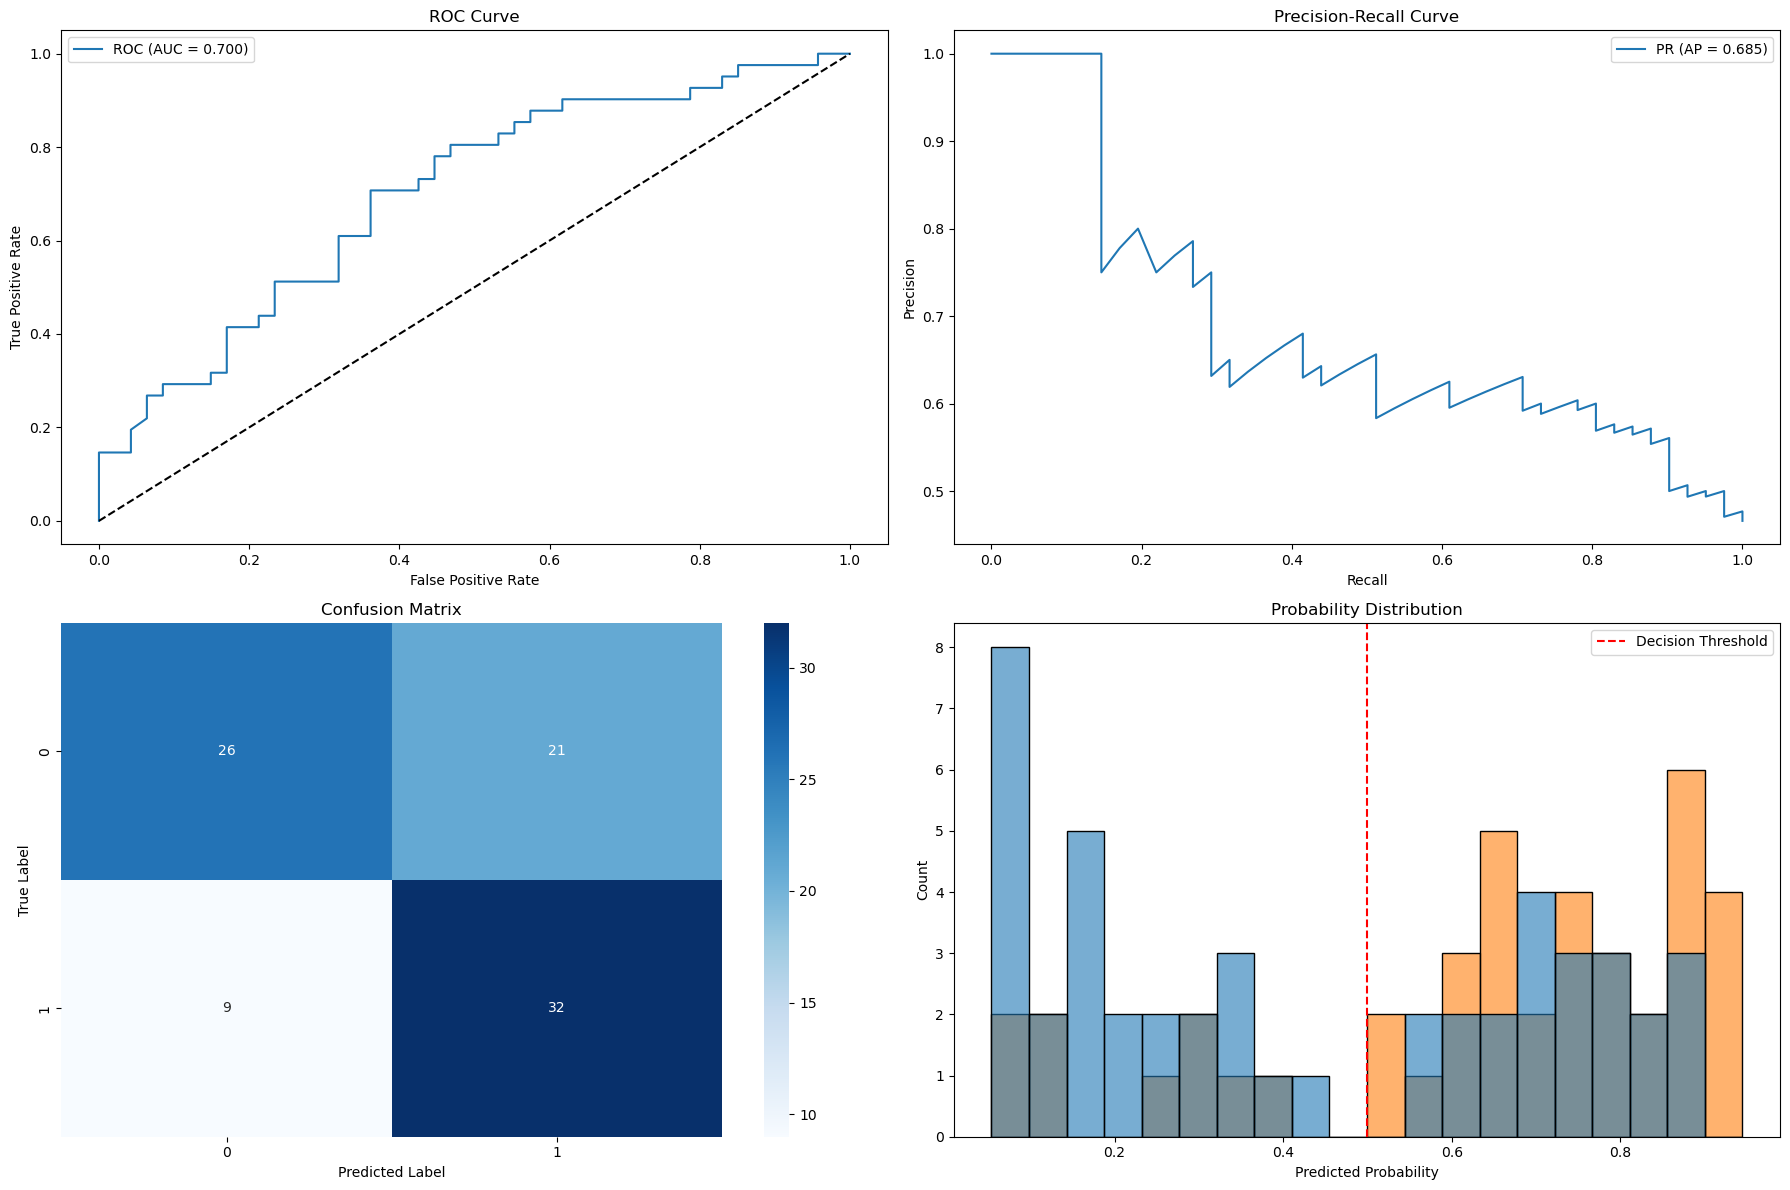

✅ Saved evaluation plots to results/ASD_finetuned_results.png

STEP 7: SIDE-BY-SIDE COMPARISON
  ACCURACY   | Zero-Shot: 0.4659 | Fine-Tuned: 0.6591 | Δ: +0.1932
  PRECISION  | Zero-Shot: 0.4500 | Fine-Tuned: 0.6038 | Δ: +0.1538
  RECALL     | Zero-Shot: 0.6585 | Fine-Tuned: 0.7805 | Δ: +0.1220
  F1         | Zero-Shot: 0.5347 | Fine-Tuned: 0.6809 | Δ: +0.1462
  ROC_AUC    | Zero-Shot: 0.4450 | Fine-Tuned: 0.6998 | Δ: +0.2548

✅ Comparison saved to results/ASD_comparison.csv

✅ ZERO-SHOT vs FINE-TUNED EVALUATION COMPLETE


In [ ]:

# Select Target
TARGET_COLUMN = 'ASD'  
LOAD_WEIGHTS = 'weights_ASD.pth'

# Data paths
DATA_PATH = "/home/jaizor/jaizor/xtra/notebooks/UKBB/scripts/dataset/abide/fmri_ASD.npz"    
PHENO_PATH = "/home/jaizor/jaizor/xtra/notebooks/UKBB/scripts/dataset/abide/pheno_ASD.csv"

WEIGHTS_DIR = '/home/jaizor/jaizor/xtra/notebooks/UKBB/scripts/weights'
WEIGHT_PATH = f"{WEIGHTS_DIR}/{LOAD_WEIGHTS}"

import os
os.makedirs('results', exist_ok=True)
os.makedirs('weights', exist_ok=True)
os.makedirs('dataset', exist_ok=True)


# Deep Learning 
import gc
import json
import torch
import numpy as np
import pandas as pd
import bbtransformer as bbt
import matplotlib.pyplot as plt


from bbt import (
    prepare_fmri_data,
    load_roi_names,
    create_bbtransformer,
    train_model,
    evaluate_model,
    plot_results,
    load_model_weights,
    save_model_weights
)

# ===============================================
# STEP 1: Load Data
# ===============================================
print("="*60)
print(f"STEP 1: Loading Data for Target = '{TARGET_COLUMN}'")
print("="*60)

pheno = pd.read_csv(PHENO_PATH)
features = np.load(DATA_PATH)
data = features['data']
subject_ids = features['subject_ids']
roi_names = load_roi_names('dataset/roi_labels.csv')

required_columns = [TARGET_COLUMN, 'Age', 'Sex']
missing = [col for col in required_columns if col not in pheno.columns]
if missing:
    raise ValueError(f"❌ Missing columns: {missing}")
print("✓ All required columns present")

# ==============================================
# STEP 2: Prepare Data Loaders
# ===============================================
print("\n" + "="*60)
print("STEP 2: Preparing Data Loaders")
print("="*60)

train_loader, val_loader, test_loader, metadata = prepare_fmri_data(
    data_path=DATA_PATH,
    pheno_path=PHENO_PATH,
    target_column=TARGET_COLUMN,
    age_column='Age',
    ext_column='Sex',
    batch_size=64,
    train_split=0.7,
    val_split=0.15,
    test_split=0.15,
    random_seed=42
)

print("\n📊 Dataset Meta")
for k, v in metadata.items():
    if k not in ['age_mean', 'age_std']:
        print(f"  {k}: {v}")

# ===============================================
# STEP 3: Initialize Model
# ===============================================
print("\n" + "="*60)
print("STEP 3: Initializing BBTransformer")
print("="*60)

torch.cuda.empty_cache()
gc.collect()

# ✅ Exact best hyperparameters from your Optuna Sex run
BEST_HP = {
    'feature_dim': metadata['feature_dim'],
    'num_classes': 1,
    'embed_dim': 512,
    'num_heads': 8,
    'num_layers': 6,
    'dropout_input': 0.271037581013532,
    'dropout_attn': 0.14600627822960482,
    'dropout_ffn': 0.27515967497010174,
    'dropout_classifier': 0.029054607960590395,
    'dropout_temporal': 0.1670895241114272,
    'embed_dim_age': 32,
    'embed_dim_ext': 16,
    'patch_size': 3,
    'patch_embed_ratio': 0.5,
    'temp_attn_hidden': 128,
    'n_kv_heads': 4,
    'return_attn_weights': False
}

model = create_bbtransformer(BEST_HP)
print(f"✓ Model created on CPU with {model.count_parameters():,} parameters")

# ===============================================
# STEP 3.5: Load Pretrained Weights (for Zero-Shot)
# ===============================================
print("\n" + "="*60)
print("STEP 3.5: Loading Pretrained Weights for Zero-Shot")
print("="*60)

# Load on CPU first (as before)
success = load_model_weights(model, device='cpu', weight_paths=[WEIGHT_PATH])
if not success:
    raise RuntimeError("❌ Failed to load pretrained weights.")

# Move to device for evaluation
model.to(device)
print("✓ Pretrained weights loaded.")

# ===============================================
# STEP 4: ZERO-SHOT EVALUATION
# ===============================================
print("\n" + "="*60)
print("STEP 4: Zero-Shot Evaluation (No Training)")
print("="*60)

zero_shot_metrics, zs_probs, zs_targets = evaluate_model(model, test_loader)

print("\n🧪 Zero-Shot Metrics:")
for metric in ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']:
    print(f"  {metric.capitalize()}: {zero_shot_metrics[metric]:.4f}")

# Save zero-shot results
plot_results(zero_shot_metrics, zs_probs, zs_targets,
             save_path=f'results/{TARGET_COLUMN}_zeroshot_results.png')
with open(f'results/{TARGET_COLUMN}_zeroshot_metrics.json', 'w') as f:
    json.dump({k: (v.tolist() if hasattr(v, 'tolist') else float(v)) 
               for k, v in zero_shot_metrics.items()}, f, indent=4)

# ===============================================
# STEP 5: FINE-TUNE MODEL
# ===============================================
print("\n" + "="*60)
print("STEP 5: Fine-Tuning with Ranger21")
print("="*60)

# NOTE: We reuse the same model object — it will be updated in-place
trained_model = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=10000,
    lr=1.700152328841238e-05,
    weight_decay=2.3798658050870825e-05,
    patience=90,
    T_0=60,
    eta_min=1e-7
)

print("\n✅ Fine-tuning complete!")

# Save fine-tuned weights
save_model_weights(trained_model, target_name=TARGET_COLUMN, safe_format=True)

# ===============================================
# STEP 6: POST-FINETUNE EVALUATION
# ===============================================
print("\n" + "="*60)
print("STEP 6: Evaluation After Fine-Tuning")
print("="*60)

ft_metrics, ft_probs, ft_targets = evaluate_model(trained_model, test_loader)

print("\n🧪 Fine-Tuned Metrics:")
for metric in ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']:
    print(f"  {metric.capitalize()}: {ft_metrics[metric]:.4f}")

# Save fine-tuned results
plot_results(ft_metrics, ft_probs, ft_targets,
             save_path=f'results/{TARGET_COLUMN}_finetuned_results.png')
with open(f'results/{TARGET_COLUMN}_finetuned_metrics.json', 'w') as f:
    json.dump({k: (v.tolist() if hasattr(v, 'tolist') else float(v)) 
               for k, v in ft_metrics.items()}, f, indent=4)

# ===============================================
# STEP 7: SIDE-BY-SIDE COMPARISON
# ===============================================
print("\n" + "="*60)
print("STEP 7: SIDE-BY-SIDE COMPARISON")
print("="*60)

comparison = {}
for metric in ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']:
    zs = zero_shot_metrics[metric]
    ft = ft_metrics[metric]
    delta = ft - zs
    comparison[metric] = {'zero_shot': zs, 'fine_tuned': ft, 'delta': delta}
    print(f"  {metric.upper():10} | Zero-Shot: {zs:.4f} | Fine-Tuned: {ft:.4f} | Δ: {delta:+.4f}")

# Save comparison
with open(f'results/{TARGET_COLUMN}_comparison.json', 'w') as f:
    json.dump(comparison, f, indent=4)

# Optional: Save as CSV for easy viewing
comp_df = pd.DataFrame(comparison).T
comp_df.to_csv(f'results/{TARGET_COLUMN}_comparison.csv')
print(f"\n✅ Comparison saved to results/{TARGET_COLUMN}_comparison.csv")

print("\n" + "="*60)
print("✅ ZERO-SHOT vs FINE-TUNED EVALUATION COMPLETE")
print("="*60)